Alexander W. Criswell 11/6/25

Testing the new (now fixed) implementation of Poisson-marginalized likelihood.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import cupy as xp
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator
from matplotlib.pyplot import cycler
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.collections import LineCollection
import matplotlib.cm
from matplotlib import patches
# import jax.numpy as jnp
# import jax; jax.config.update("jax_enable_x64", True)
from corner import corner, overplot_lines
import legwork as lw
import astropy.units as u
from tqdm import tqdm
from math import factorial
import scipy.stats as scst

In [3]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State, BranchSupplemental
from eryn.backends import SupplementalBackend
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove, DistributionGenerate, MTDistGenMove, Move
from eryn.utils.utility import groups_from_inds
from multiprocessing import Pool

In [4]:
np.random.seed(42)

In [5]:
xp.cuda.is_available()

True

In [6]:
## set environment variables
import os
os.environ['PELARGIR_GPU'] = '1'
os.environ['SCIPY_ARRAY_API'] = '1'
os.environ['PELARGIR_ERYN'] = '1'

In [7]:
if os.environ['PELARGIR_GPU']:
    print('GPU enabled.')

GPU enabled.


In [8]:
import sys
prop_path = '/home/awc/Documents/LISA/projects/lisa_population_inference/pelargir-gb/pelargir/'
sys.path.insert(1, prop_path)
from models import PopModel
from inference import GalacticBinaryPrior, PopulationHyperPrior
from utils import get_amp_freq, lisa_noise_psd, set_style, to_numpy
from plotting import plot_spectra, plot_spectra_flexible, plot_corners, plot_model_chains, plot_model_loglikes, plot_Nres_hist
from moves import make_PriorMove, PoissonMove
import distributions as st

GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.


In [9]:
set_style()

In [10]:
test_rng = xp.random.default_rng(170817)

In [11]:
test_prior = GalacticBinaryPrior(test_rng)

In [12]:
pop_theta = {'m_mu':xp.array([0.6]),'m_sigma':xp.array([0.15]),
             # 'd_mu':xp.array([30]),'d_sigma':xp.array([10]),
             'd_gamma_a':xp.array([4]),'d_gamma_b':xp.array([4]),
             'a_alpha':xp.array([1/2])}
test_prior.condition(pop_theta)

In [13]:
samps = test_prior.sample_conditional((int(1e7),))

In [14]:
samps.shape

(4, 10000000)

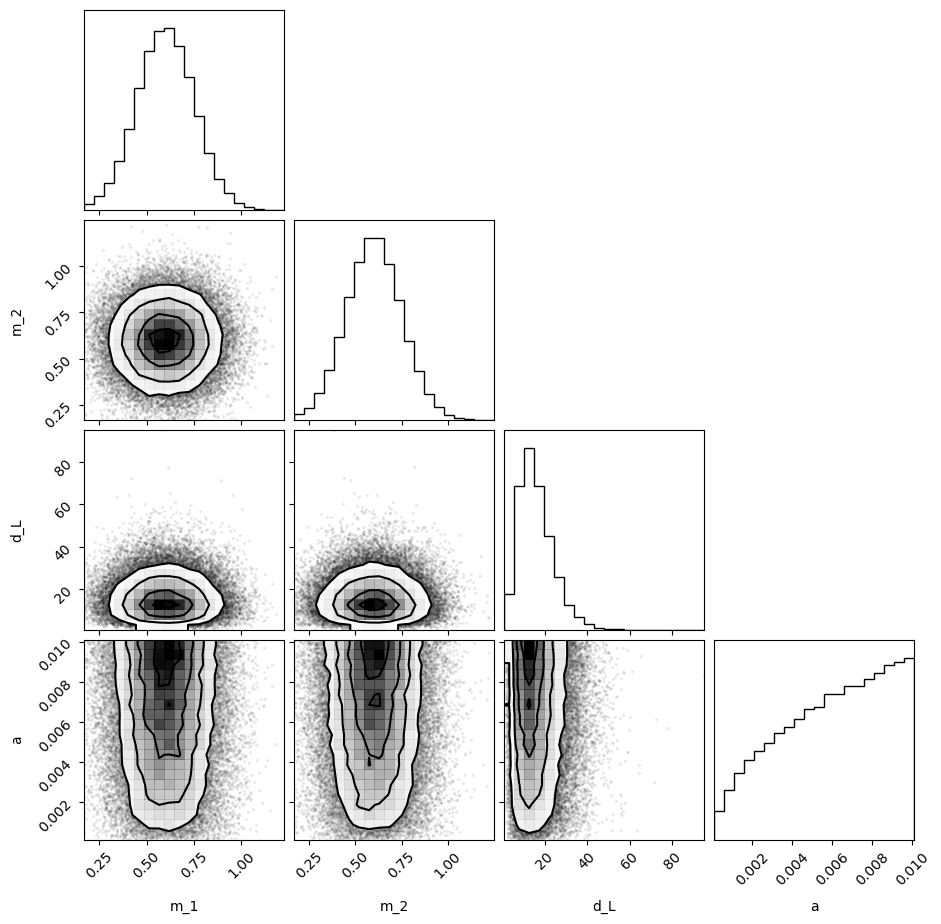

In [15]:
plt.close()
fig = corner(samps[:,::200].get().T,labels=list(test_prior.conditional_dict.keys()))
plt.show()

In [16]:
amps, fgws = get_amp_freq(samps)

In [17]:
test_hprior = PopulationHyperPrior(test_rng)

In [18]:
test_bin_width = 2e-5
test_fbins = xp.arange(1e-4,5e-3,test_bin_width)
test_popmodel = PopModel(1e7,test_rng,hyperprior=test_hprior,Nsamp=1,Nreal=1,fbins=test_fbins)

In [19]:
test_f, test_fg, N_res = test_popmodel.run_model(pop_theta)

In [20]:
data_N_res, data_coarse_fg = test_popmodel.thresher.serial_array_sort(xp.array([fgws,amps]),
                                                                      test_popmodel.fbins,
                                                                      snr_thresh=test_popmodel.thresh_val)
data_fg = test_popmodel.reweight_foreground(data_coarse_fg)[1:]

In [21]:
data_N_res

array(874)

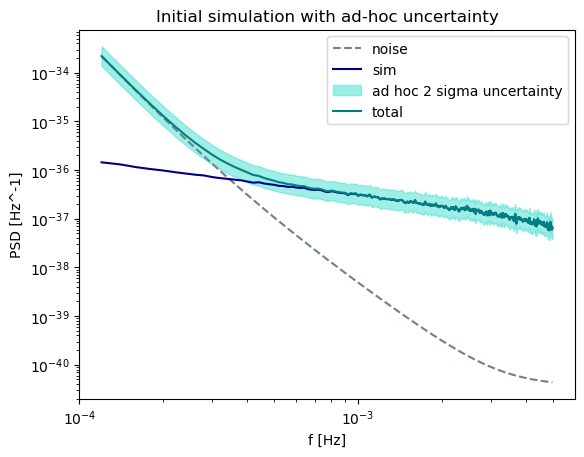

In [30]:
total_fs = test_f.get()
total_spec = data_fg.get() + lisa_noise_psd(test_f).get()
errs = 0.1
# errs = 1e-38
plt.figure()
plt.loglog(total_fs,lisa_noise_psd(test_f).get(),c='slategrey',ls='--',label='noise')
plt.loglog(total_fs,data_fg.get(),c='navy',label='sim')
plt.fill_between(total_fs,10**(np.log10(total_spec)-2*errs),10**(np.log10(total_spec)+2*errs),
                 color='turquoise',alpha=0.5,label='ad hoc 2 sigma uncertainty')
# plt.fill_between(total_fs,total_spec-2*errs,total_spec+2*errs,
#                  color='turquoise',alpha=0.5,label='ad hoc 2 sigma uncertainty')
plt.loglog(total_fs,total_spec,label='total',c='teal')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('PSD [Hz^-1]')
plt.title('Initial simulation with ad-hoc uncertainty')
# plt.ylim(1e-40,1e-36)
plt.show()

In [31]:
## setup w.r.t. the data
datadict = {'fs':test_f,
            'fg':data_fg,
            'fg_sigma':xp.array(errs),
            'Nres':data_N_res,
            'noise':lisa_noise_psd(test_f)}

In [32]:
test_rng = xp.random.default_rng(42)

In [33]:
translation_dict = {0:'m_mu',
                    1:'m_sigma',
                    2:'d_gamma_a',
                    3:'d_gamma_b',
                    4:'a_alpha'}
## starting with the broader priors
eryn_hyperprior_dict = {0:st.uniform(test_rng,loc=0.2,scale=0.9,cast=True),
                        1:st.invgamma(test_rng,5,cast=True),
                        2:st.uniform(test_rng,loc=1,scale=10,cast=True), ## these are pretty arbitrary
                        3:st.uniform(test_rng,loc=1,scale=10,cast=True), ## these are pretty arbitrary
                        4:st.uniform(test_rng,loc=-0.5,scale=2,cast=True)}
eryn_trans_dict = {translation_dict[key]:eryn_hyperprior_dict[key] for key in eryn_hyperprior_dict.keys()}

In [34]:
eryn_trans_dict

{'m_mu': <distributions.uniform at 0x729175f89430>,
 'm_sigma': <distributions.invgamma at 0x729175f8b0b0>,
 'd_gamma_a': <distributions.uniform at 0x729175fd2ba0>,
 'd_gamma_b': <distributions.uniform at 0x7290ed1a4d40>,
 'a_alpha': <distributions.uniform at 0x72913420d670>}

In [35]:
eryn_prior = ProbDistContainer(eryn_hyperprior_dict)

In [36]:
Nreal = 5

In [37]:
test_bin_width = 2e-5
test_fbins = xp.arange(1e-4,5e-3,test_bin_width)
eryn_popmodel = PopModel(1e7,test_rng,hyperprior=eryn_trans_dict,fbins=test_fbins,Nreal=Nreal)

In [38]:
eryn_popmodel.construct_likelihood(datadict)

In [39]:
log_like_fn = eryn_popmodel.fg_N_ln_prob

In [40]:
ndim = len(eryn_popmodel.hyperprior.hyperprior_dict)
nwalkers = 10
ntemps = 1

In [41]:
# fill kwargs dictionary
tempering_kwargs=dict(ntemps=ntemps)

In [42]:
## MH with prior draws as the proposal function
PriorMove = make_PriorMove(eryn_prior)
# PriorMove = DistributionGenerate({'model_0':eryn_prior})

Set up the branch supplemental to track the foreground spectra and number of resolved binaries:

In [43]:
branch_supp = BranchSupplemental(
    {"spectra": np.zeros((ntemps,nwalkers,1,len(test_f),Nreal,1)),
     "Nres": np.zeros((ntemps,nwalkers,1,1,Nreal,1))},
    base_shape=(ntemps, nwalkers,1),
    copy=True
)

In [44]:
# starting positions
# randomize throughout prior
coords = eryn_prior.rvs(size=(ntemps,nwalkers,))

Because we are now including the branch supplemental, we need to make a starting State object.

In [45]:
start_state = State(coords,
                    branch_supplemental={'model_0':branch_supp})

Initialize the new supplemental backend. Need to provide the supplemental names and dims.

In [46]:
supp_dims = {'spectra':(len(test_f),Nreal,1),
             'Nres':(1,Nreal,1)}
supp_backend = SupplementalBackend(supp_dims)

Build an Eryn ensemble with the added branch supplemental and backend.

In [47]:
ensemble = EnsembleSampler(nwalkers,
                           ndim,
                           log_like_fn,
                           eryn_prior,
                           # moves=[(StretchMove(a=a),0.7),(PriorMove,0.1),(PoissonMove(),0.2)],
                           # moves=
                           moves=StretchMove(),
                           track_moves=True,
                           tempering_kwargs=tempering_kwargs,
                           provide_supplemental=True,
                           dynamic_branch_supplemental=True,
                           backend=supp_backend
                          )

In [48]:
xp.cuda.is_available()

True

In [49]:
ensemble.provide_supplemental

True

In [50]:
nsteps = 10
burn = None
thin_by = 1
out = ensemble.run_mcmc(start_state, nsteps, burn=burn, progress=True, thin_by=thin_by)
# pool.close()
# pool.join()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:03<00:00, 12.35s/it]


In [51]:
ensemble.acceptance_fraction

array([[0.3, 0.2, 0.3, 0.3, 0.2, 0.3, 0.5, 0.4, 0. , 0.7]])

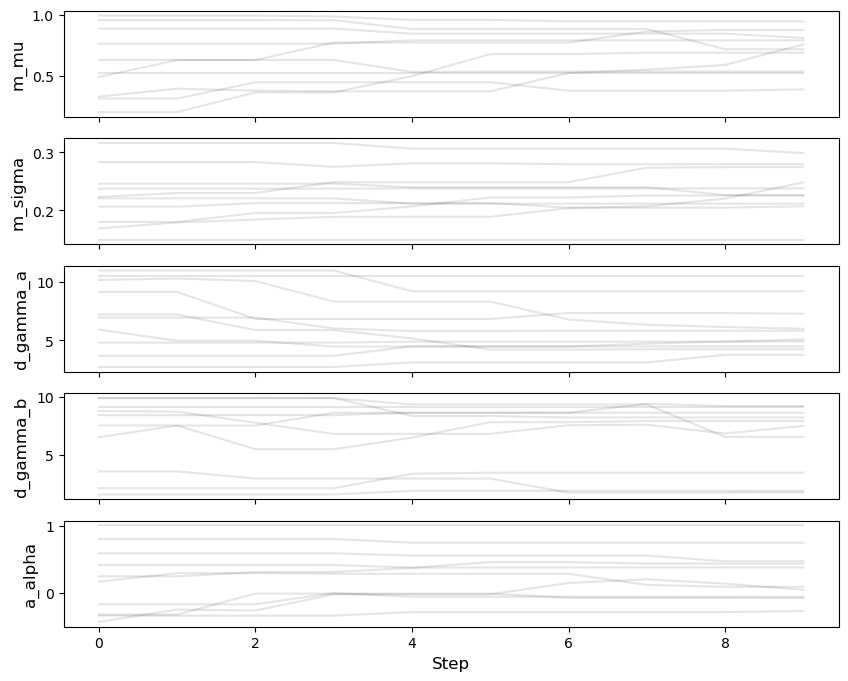

In [52]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

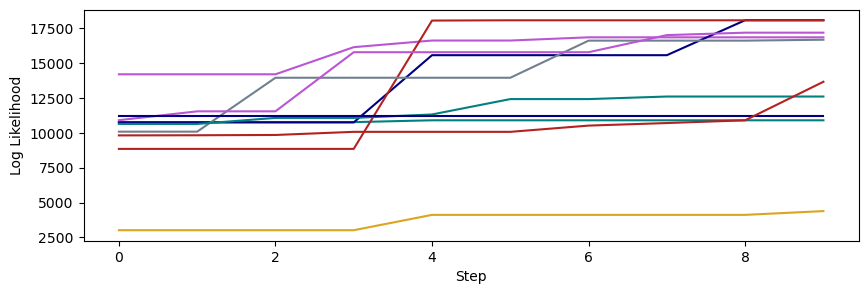

In [53]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

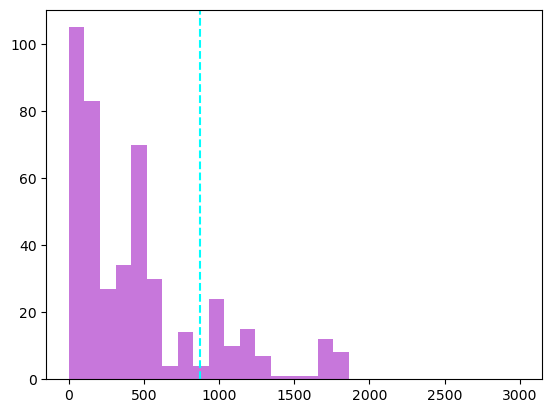

In [54]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,3000,30),temp_index=0)#,showtrue=False)

Starting spectra:

In [55]:
ensemble.get_log_like(temp_index=0).shape

(10, 10)

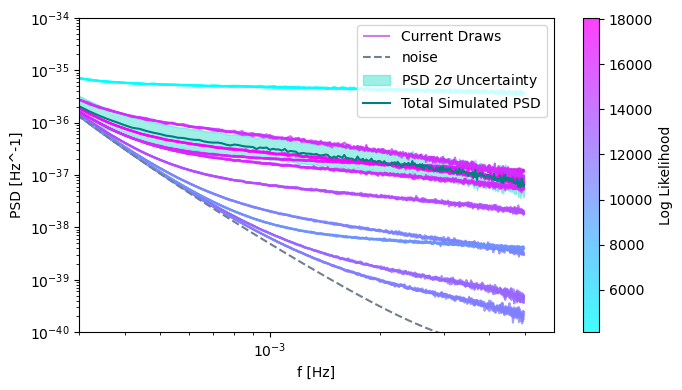

In [57]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(3e-4,),ylim=(1e-40,1e-34),iteration=5)

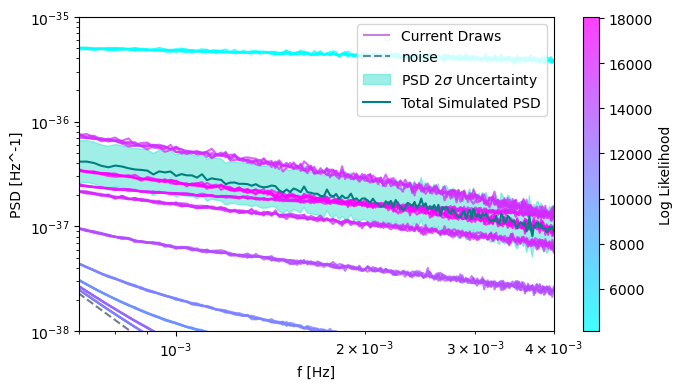

In [58]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=5)

In [59]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [60]:
samples = ensemble.get_chain(discard=0,temp_index=0,thin=1)['model_0'].reshape(-1,ndim)

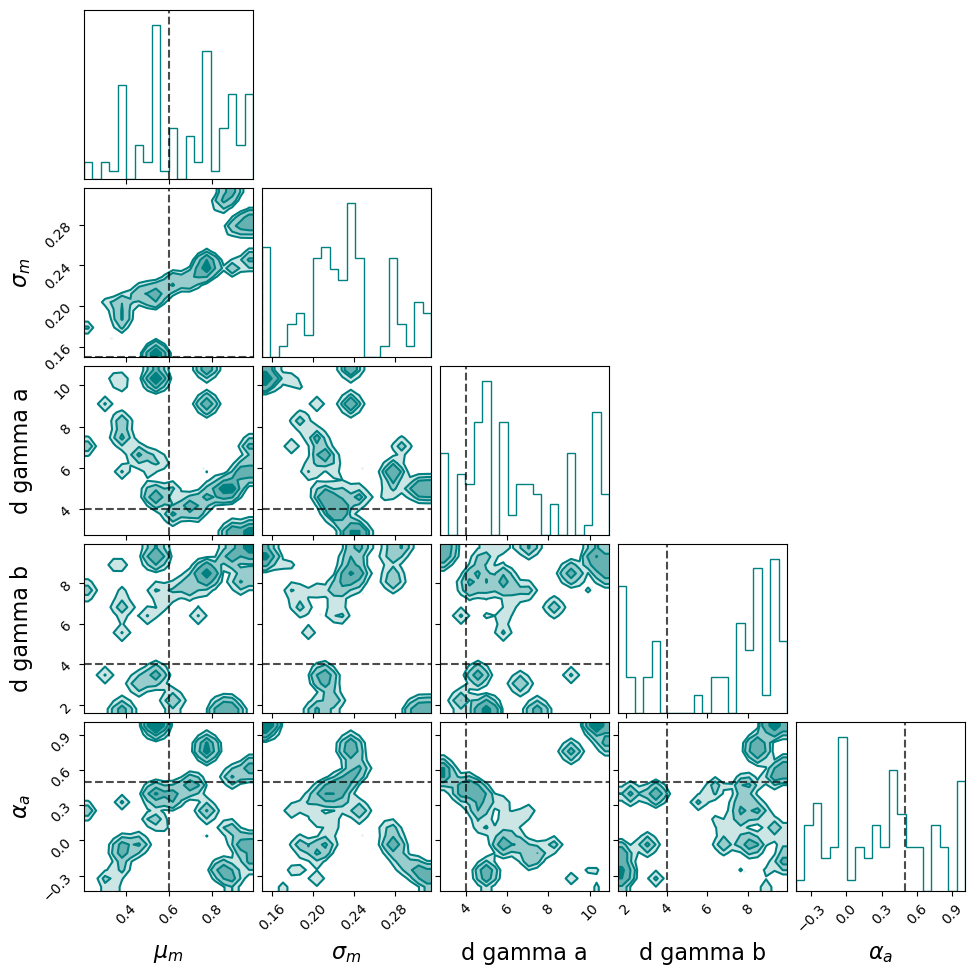

In [61]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

Current spectra:

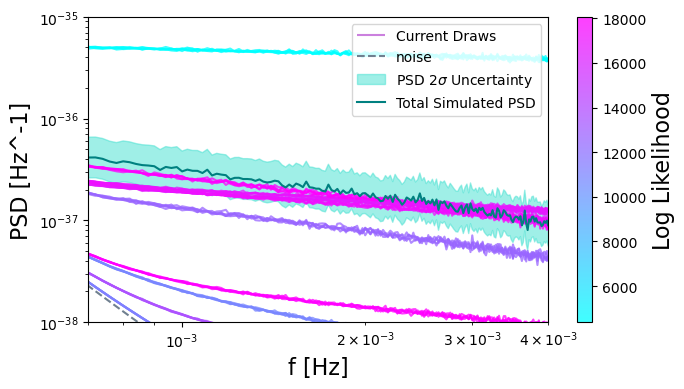

In [62]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=-1)

In [92]:
nsteps = 90
burn = None
thin_by = 1
out = ensemble.run_mcmc(out, nsteps, burn=burn, progress=True, thin_by=thin_by)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [25:34<00:00, 17.05s/it]


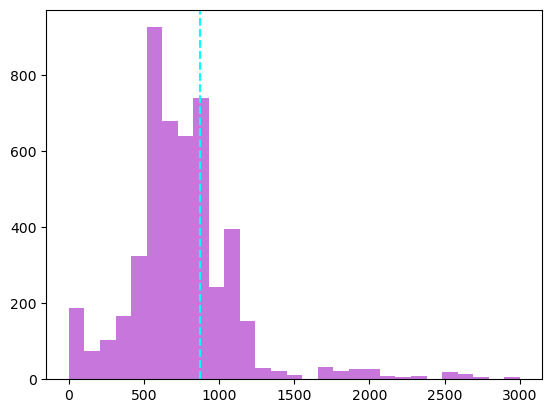

In [93]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,3000,30),
               discard=0,thin=1,temp_index=0)#,showtrue=False)

In [94]:
ensemble.acceptance_fraction

array([[0.09, 0.1 , 0.12, 0.06, 0.09, 0.16, 0.1 , 0.21, 0.21, 0.17]])

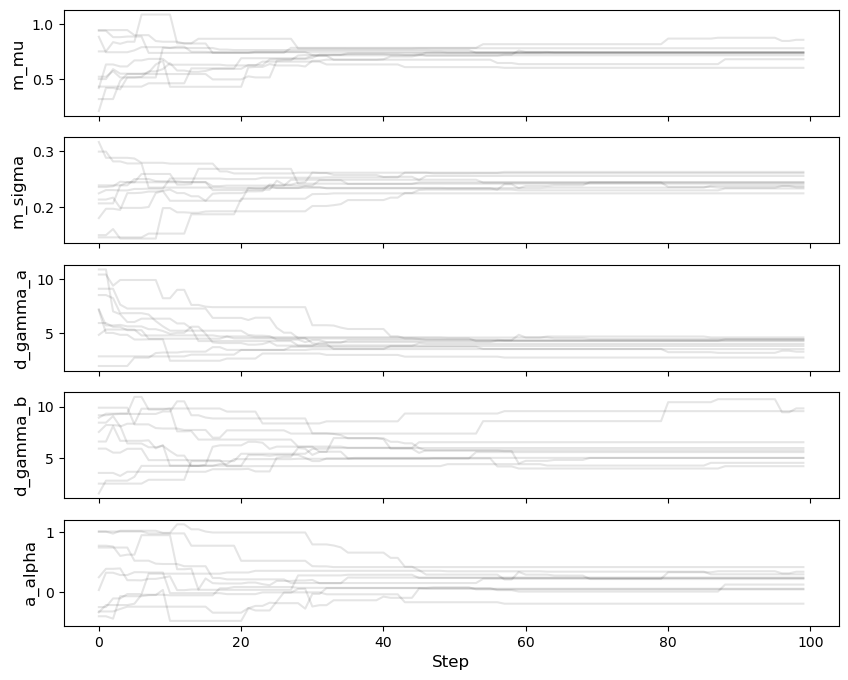

In [95]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

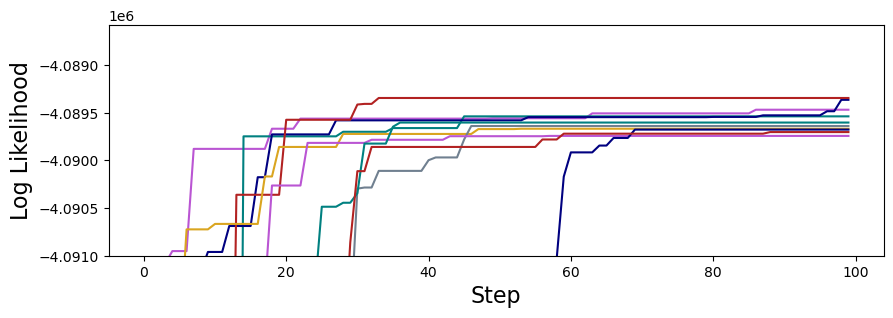

In [106]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,temp_index=0,ylim=(-4.091e6,))

Where are they now?

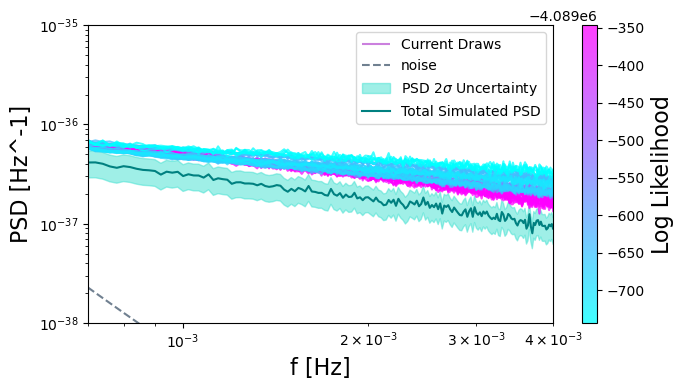

In [97]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=-1)

In [98]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [99]:
truths

array([0.6 , 0.15, 4.  , 4.  , 0.5 ])

In [103]:
samples = ensemble.get_chain(discard=50,temp_index=0,thin=1)['model_0'].reshape(-1,ndim)

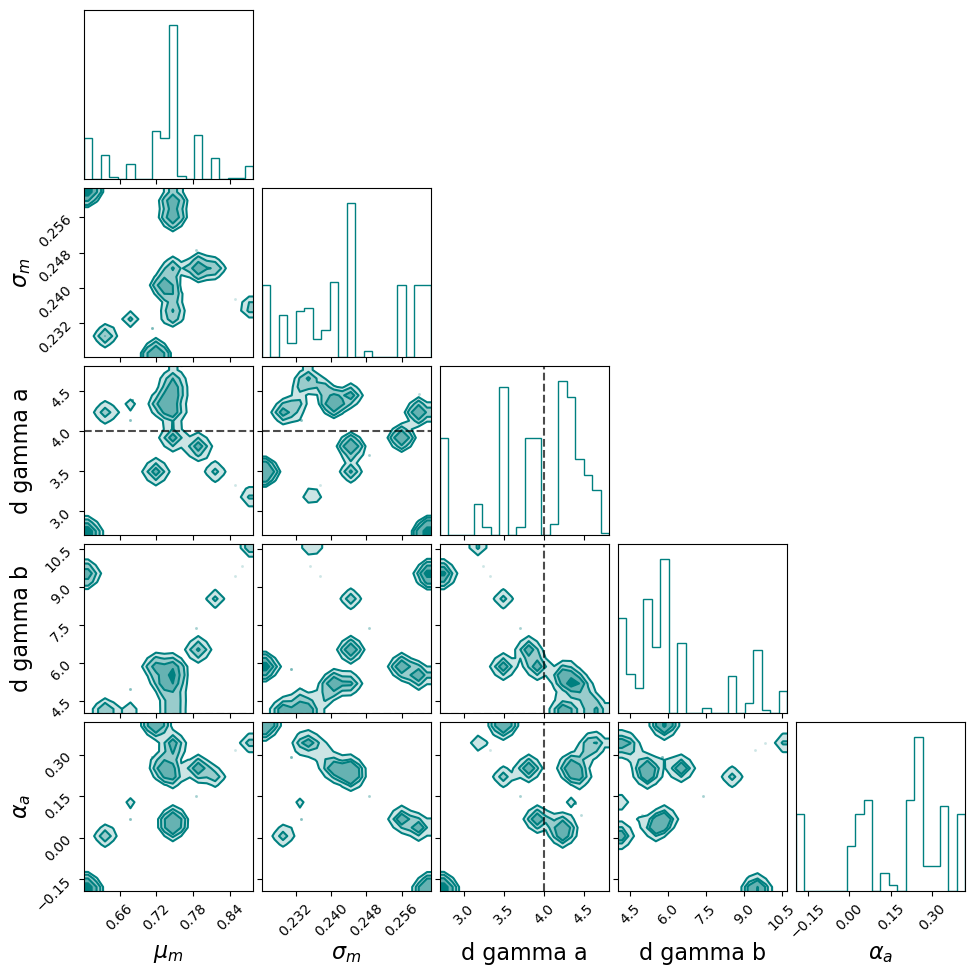

In [104]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

In [102]:
np.var(ensemble.get_chain(discard=0,temp_index=0,thin=1)['model_0'][...,4],axis=0)

array([[0.01430897],
       [0.04293876],
       [0.02153451],
       [0.04158251],
       [0.00589743],
       [0.02209193],
       [0.02231724],
       [0.00339245],
       [0.12028506],
       [0.0354448 ]])

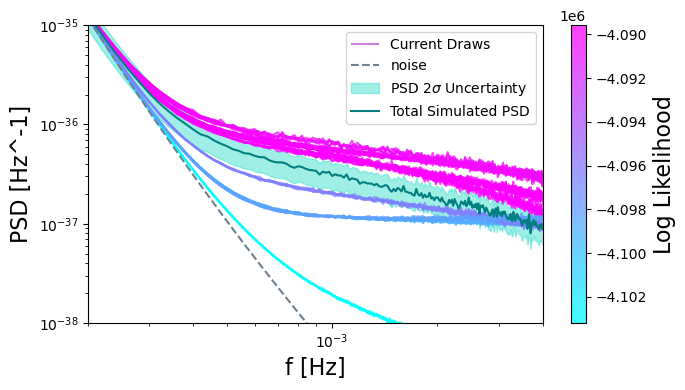

In [112]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(2e-4,4e-3),ylim=(1e-38,1e-35),iteration=20)

In [118]:
spec_chain = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'].squeeze()

In [119]:
spec_chain.shape

(100, 10, 244, 5)

In [120]:
from copy import deepcopy

In [138]:
total_fs.shape

(244,)

In [148]:
eryn_popmodel.fg_like.ln_pgrid.shape

(1, 1)

In [164]:
ll = eryn_popmodel.fg_like
ll.vector_gaussian_logpdf(ll.cgrid[0,:][xp.newaxis,:],ll.mu_vec[0],xp.atleast_1d(ll.cov)[0])[xp.newaxis,:].shape

(1, 1000)

In [161]:
test_draw_spec = spec_chain[-1,0,...]
test_draw_spec = xp.array(test_draw_spec)[...,xp.newaxis]

In [162]:
ll.ln_prob_conditional_like(test_draw_spec)

array(-1001894.51418137)

In [165]:
ll.ln_pgrid = ll.vector_gaussian_logpdf(ll.cgrid[0,:][xp.newaxis,:],ll.mu_vec[0],xp.atleast_1d(ll.cov)[0])[xp.newaxis,:]

In [166]:
ll.ln_pgrid.shape

(1, 1000)

In [155]:
ll.cgrid[0].shape

(1000,)

In [167]:
ll.ln_prob_conditional_like(test_draw_spec)

array(15209.46095433)

Okay that's one problem solved.

Now let's broaden the grid and switch to integration over log10Sgw.

$d\ln(x) = \frac{dx}{x}$, so

$\int f(x) dx = \int f(x) x d\ln(x)$

For $\log_{10}$, this is:

$d\log_{10}(x) = \frac{dx}{x\ln10}$, so

$\int f(x) dx = \ln10 \int f(x) x d\log_{10}(x)$

We can neglect this factor of x if we pass f(x) as a lognormal pdf without the 1/x leading factor.

In [169]:
new_cgrid = xp.logspace(-42,-33,1000)

In [190]:
def grid_gaussian_logpdf(theta_vec, mu_vec, sigma):
    """
    Array operation-based Gaussian log PDF, sans normalization.

    Parameters
    ----------
    theta_vec : array
        Grid of proposed (model) spectra. Must be an array whose leading axis is frequency.
    mu_vec : array
        Measured (data) spectrum. Will be cast to shape (Nf,1). Leading axis must be of same size as theta_vec.
    sigma : float or array
        Uncertainty of the Gaussian as standard deviation. If array, designates uncertainty in each
        frequency bin, and must be of same shape as mu_vec.

    Returns
    -------
    logpdf
        Unnormalized Gaussian log likelihood.

    """
    
    ## force proper casting
    theta_vec = xp.atleast_1d(theta_vec)
    mu_vec = xp.atleast_1d(mu_vec)
    sigma = xp.atleast_1d(sigma)
    if theta_vec.ndim == 1:
        theta_vec = theta_vec[:,xp.newaxis]
    if mu_vec.ndim < theta_vec.ndim:
        for i in range(theta_vec.ndim-mu_vec.ndim):
            mu_vec = mu_vec[...,xp.newaxis]
    if sigma.ndim < theta_vec.ndim:
        for i in range(theta_vec.ndim-sigma.ndim):
            sigma = sigma[...,xp.newaxis]
            

    return - (theta_vec - mu_vec)**2/(2*sigma**2)

def grid_lognormal_logpdf(theta_vec, mu_vec, sigma):
    """
    Array operation-based log normal log PDF, sans normalization.

    Note that this does not include a leading factor of 1/x, as we integrate over 
    a log-spaced grid and it would cancel out there.

    Parameters
    ----------
    theta_vec : array
        Grid of proposed (model) spectra. Must be an array whose leading axis is frequency.
    mu_vec : array
        Measured (data) spectrum. Will be cast to shape (Nf,1). Leading axis must be of same size as theta_vec.
    sigma : float or array
        Uncertainty of the Gaussian as standard deviation. If array, designates uncertainty in each
        frequency bin, and must be of same shape as mu_vec.

    Returns
    -------
    logpdf
        Unnormalized Gaussian log likelihood.

    """
    
    ## force proper casting
    theta_vec = xp.atleast_1d(theta_vec)
    mu_vec = xp.atleast_1d(mu_vec)
    sigma = xp.atleast_1d(sigma)
    if theta_vec.ndim == 1:
        theta_vec = theta_vec[:,xp.newaxis]
    if mu_vec.ndim < theta_vec.ndim:
        for i in range(theta_vec.ndim-mu_vec.ndim):
            mu_vec = mu_vec[...,xp.newaxis]
    if sigma.ndim < theta_vec.ndim:
        for i in range(theta_vec.ndim-sigma.ndim):
            sigma = sigma[...,xp.newaxis]
            

    return - (xp.log(theta_vec) - xp.log(mu_vec))**2/(2*sigma**2)

In [174]:
new_logpdf = grid_gaussian_logpdf(new_cgrid[xp.newaxis,:],ll.mu_vec,xp.atleast_1d(ll.cov))

In [247]:
logn_logpdf = grid_lognormal_logpdf(new_cgrid[xp.newaxis,:],ll.mu_vec,0.2)

In [248]:
fi = 100

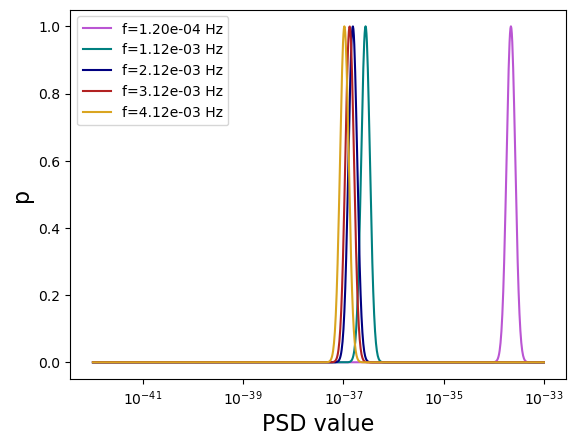

In [250]:
plt.figure()
for fi in [0,50,100,150,200]:
    # plt.plot(new_cgrid.get(),new_logpdf[fi,:].get(),
    #          label="f={:0.2e} Hz".format(test_f.get()[fi])) #/logpdf[0,0])
    plt.plot(new_cgrid.get(),np.exp(logn_logpdf[fi,:].get()),
             label="f={:0.2e} Hz".format(test_f.get()[fi])) #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
# for i in range(5):
#     plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey')
plt.xlabel('PSD value')
plt.ylabel('p')
plt.xscale('log')
# plt.ylim(-0.5e73,0)
# plt.xlim(1e-38,1e-33)
# plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

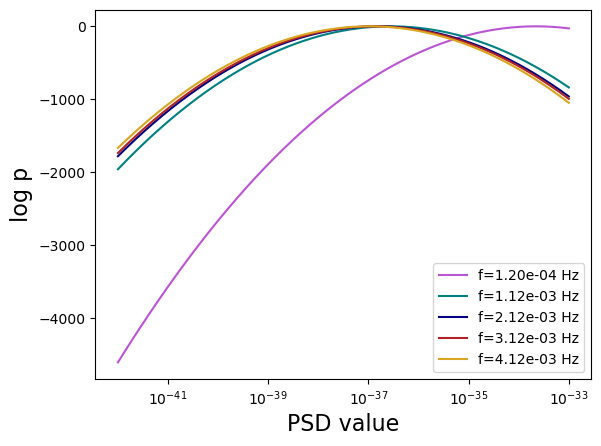

In [251]:
plt.figure()
for fi in [0,50,100,150,200]:
    # plt.plot(new_cgrid.get(),new_logpdf[fi,:].get(),
    #          label="f={:0.2e} Hz".format(test_f.get()[fi])) #/logpdf[0,0])
    plt.plot(new_cgrid.get(),logn_logpdf[fi,:].get(),
             label="f={:0.2e} Hz".format(test_f.get()[fi])) #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
# for i in range(5):
#     plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey')
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
# plt.ylim(-0.5e73,0)
# plt.xlim(1e-38,1e-33)
# plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

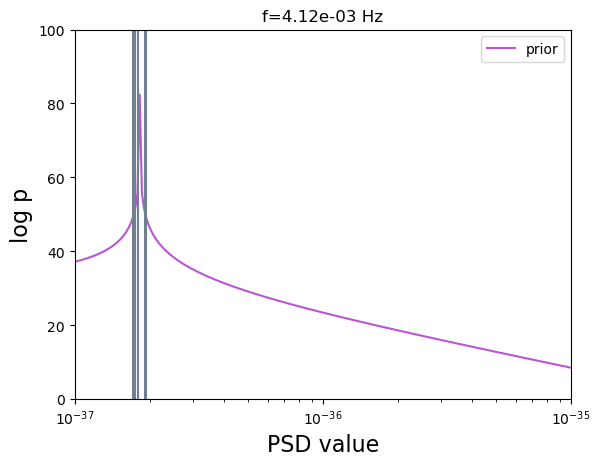

In [254]:
ta = new_cgrid

plt.figure()

eryn_popmodel.fg_like.conditional_t.update(test_draw_spec)
logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey')
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
plt.ylim(0,100)
plt.xlim(1e-37,1e-35)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

Much better coverage, good.

Now let's look at the convoluton:

In [256]:
from cupyx.scipy import special as xsc

In [258]:
logpdf.shape, logn_logpdf.shape

((244, 1000), (244, 1000))

In [262]:
convolved_loglike_of_f = xsc.logsumexp(xp.array(logpdf)+xp.array(logn_logpdf),axis=1)

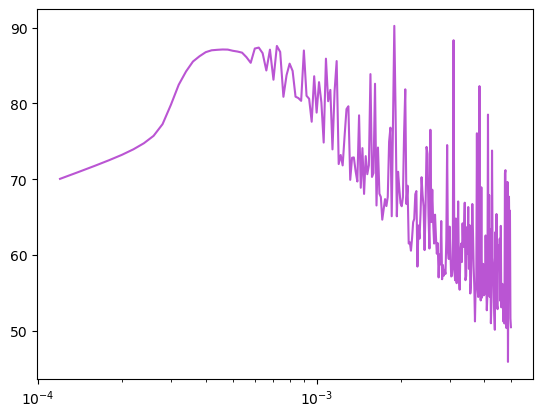

In [264]:
plt.figure()
plt.plot(total_fs,convolved_loglike_of_f.get())
plt.xscale('log')
plt.show()

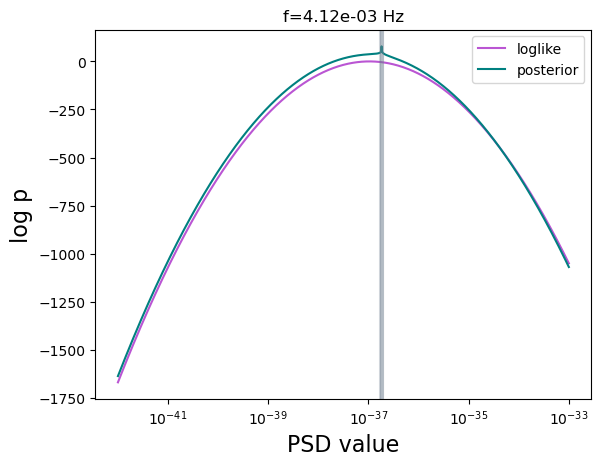

In [270]:
plt.figure()
plt.plot(ta.get(),logn_logpdf[fi,:].get(),label='loglike')
plt.plot(ta.get(),logpdf[fi,:]+logn_logpdf[fi,:].get(),label='posterior') #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey',alpha=0.3)
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
# plt.ylim(40,85)
# plt.xlim(1e-37,1e-36)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

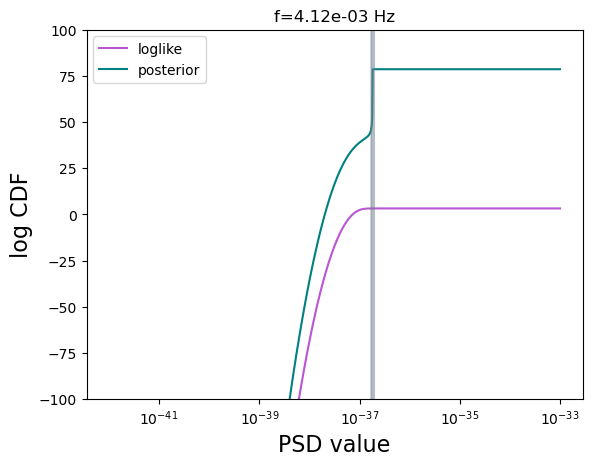

In [277]:
plt.figure()
plt.plot(ta.get(),np.logaddexp.accumulate(logn_logpdf[fi,:].get()),label='loglike')
plt.plot(ta.get(),np.logaddexp.accumulate(logpdf[fi,:]+logn_logpdf[fi,:].get()),label='posterior') #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey',alpha=0.3)
plt.xlabel('PSD value')
plt.ylabel('log CDF')
plt.xscale('log')
plt.ylim(-100,100)
# plt.xlim(1e-37,1e-36)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

In [278]:
logn_logpdf.shape

(244, 1000)

In [281]:
test_bin_width = 2e-5
test_fbins = xp.arange(1e-4,5e-3,test_bin_width)
new_popmodel = PopModel(1e7,test_rng,hyperprior=eryn_trans_dict,fbins=test_fbins,Nreal=Nreal)

In [295]:
# datadict

In [290]:
new_datadict = datadict.copy()

In [291]:
new_datadict['fg_sigma'] = 0.1

In [292]:
new_popmodel.construct_likelihood(new_datadict)

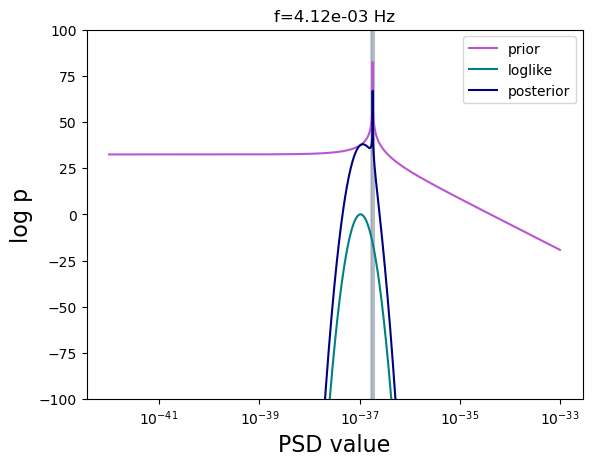

In [298]:



plt.figure()
# test_Nr = 5
# ta = xp.logspace(-42,-32,100)
ta = new_popmodel.fg_like.cgrid.squeeze()
# mu_test = lisa_noise_psd(test_f)
# alpha_test = 1e-40
# beta_test = 0.1*lisa_noise_psd(test_f)
# print(ta.shape)

new_popmodel.fg_like.conditional_t.update(test_draw_spec)
logpdf = new_popmodel.fg_like.conditional_t.logpdf(ta).get()
plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
plt.plot(ta.get(),new_popmodel.fg_like.ln_pgrid[fi,:].get(),label='loglike')
plt.plot(ta.get(),logpdf[fi,:]+new_popmodel.fg_like.ln_pgrid[fi,:].get(),label='posterior') #/logpdf[0,0])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey',alpha=0.3,zorder=-10)
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
plt.ylim(-100,100)
# plt.xlim(1e-37,1e-35)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

Okay good, this is functioning as I would expect now! Making a new notebook to test the sampler.

In [160]:
# ll.cgrid[0,:]

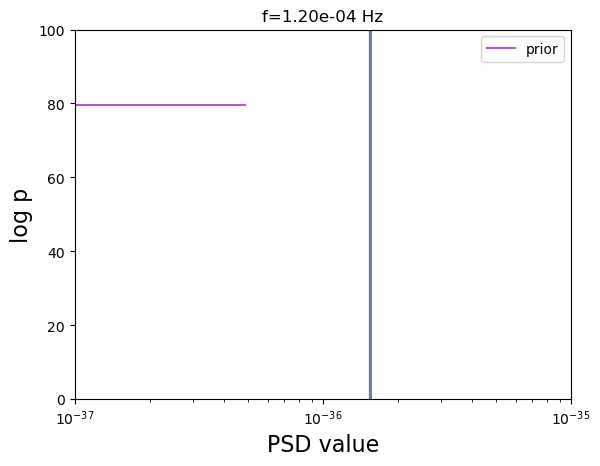

In [147]:



plt.figure()
# test_Nr = 5
# ta = xp.logspace(-42,-32,100)
ta = eryn_popmodel.fg_like.cgrid[50,:]
# mu_test = lisa_noise_psd(test_f)
# alpha_test = 1e-40
# beta_test = 0.1*lisa_noise_psd(test_f)


eryn_popmodel.fg_like.conditional_t.update(test_draw_spec)
logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey')
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
plt.ylim(0,100)
plt.xlim(1e-37,1e-35)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()